In [1]:
# ============================================================
# CELL 1: VERIFY DATASETS BEFORE MODELLING
# Before writing any model code we load and inspect all
# three dataset files to confirm they contain the correct
# columns and the updated category consolidations.
# This protects us from training on outdated data.
# ============================================================

import pandas as pd

# Load all three files
df_final = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\private_patient_final.csv'
)
df_train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
df_test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

for name, df in [
    ('FINAL DATASET', df_final),
    ('TRAINING SET', df_train),
    ('TEST SET', df_test)
]:
    print("=" * 60)
    print(f"{name}")
    print("=" * 60)
    print(f"  Records  : {len(df):,}")
    print(f"  Columns  : {df.shape[1]}")
    print(f"  Columns  : {list(df.columns)}")

    # Check Specialty categories
    print(f"\n  Specialty unique values ({df['Specialty'].nunique()}):")
    print(df['Specialty'].value_counts().to_string())

    # Check ICD10 Chapter categories
    print(f"\n  ICD10 Chapter unique values ({df['ICD10 Chapter'].nunique()}):")
    print(df['ICD10 Chapter'].value_counts().to_string())

    # Check target distribution
    if 'Processing Class' in df.columns:
        print(f"\n  Target split:")
        vc = df['Processing Class'].value_counts()
        for cls, count in vc.items():
            print(f"    {cls}: {count:,} ({count/len(df)*100:.1f}%)")
    print()

FINAL DATASET
  Records  : 50,000
  Columns  : 8
  Columns  : ['Invoice Number', 'Posted Billing Group', 'Specialty', 'Debtor Status', 'Age Bracket', 'ICD10 Chapter', 'Facility Type', 'Processing Class']

  Specialty unique values (9):
Specialty
General Practice              15833
Ophthalmologist                9233
Surgical                       7858
Specialist Medicine            4037
General Dental Practice        3860
Mental Health                  2968
Allied Health and Other        2964
Paediatrician                  1831
Obstetrics and Gynaecology     1416

  ICD10 Chapter unique values (9):
ICD10 Chapter
Routine and Outpatient          18499
Digestive and Genitourinary      6529
Cardiovascular and Metabolic     5241
Infectious and Respiratory       4979
Neurological and Structural      4298
Unknown                          3816
Mental Health                    3177
Cancer and Blood                 2809
Maternal and Developmental        652

  Target split:
    Timely: 37,962 (7

# Medical Billing Research Project
## 03a — Logistic Regression Model

**Loads from:** ../dataset/train_set.csv
**Evaluates on:** ../dataset/test_set.csv
**Target variable:** Processing Class (Timely / Delayed)
**Predictors:** 6 categorical variables

### Objective
Build a Logistic Regression classification model as the
interpretable baseline. Evaluate performance using accuracy,
F1-score, ROC-AUC, and confusion matrix. Extract and rank
variable importance using model coefficients.

In [1]:
# ============================================================
# CELL 2: IMPORTS AND LOAD DATA
# We load from the saved CSV files explicitly — never from
# memory — so this notebook runs correctly on any machine
# or after any kernel restart.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, f1_score
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load training and test sets ───────────────────────────
train = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\train_set.csv'
)
test = pd.read_csv(
    r'C:\2026\MedicalBillingResearch\dataset\test_set.csv'
)

# ── Separate predictors and target ───────────────────────
# Drop Invoice Number — tracking column, not a predictor
X_train = train.drop(columns=['Invoice Number', 'Processing Class'])
y_train = train['Processing Class']

X_test  = test.drop(columns=['Invoice Number', 'Processing Class'])
y_test  = test['Processing Class']

print("=" * 60)
print("DATA LOADED — CONFIRMATION")
print("=" * 60)
print(f"  Training records  : {len(X_train):,}")
print(f"  Test records      : {len(X_test):,}")
print(f"  Predictors        : {X_train.shape[1]}")
print(f"  Predictor columns : {list(X_train.columns)}")
print(f"\n  Training target distribution:")
print(y_train.value_counts().to_string())
print(f"\n  Test target distribution:")
print(y_test.value_counts().to_string())

DATA LOADED — CONFIRMATION
  Training records  : 35,000
  Test records      : 15,000
  Predictors        : 6
  Predictor columns : ['Posted Billing Group', 'Specialty', 'Debtor Status', 'Age Bracket', 'ICD10 Chapter', 'Facility Type']

  Training target distribution:
Processing Class
Timely     26573
Delayed     8427

  Test target distribution:
Processing Class
Timely     11389
Delayed     3611


In [2]:
# ============================================================
# CELL 3: ENCODE CATEGORICAL VARIABLES
# Logistic Regression requires numeric input.
# We apply One-Hot Encoding to all 6 categorical predictors.
# drop='first' drops one category per variable to avoid the
# dummy variable trap — perfect multicollinearity that occurs
# when all dummy variables for a predictor sum to 1.
# We fit the encoder on training data only and apply the
# same encoding to the test data to prevent data leakage.
# ============================================================

# One-Hot Encode all categorical predictors
# fit_transform on train, transform only on test
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)

# Align columns — ensures test has same columns as train
# This handles any category that appears in train but not
# test or vice versa by filling missing columns with 0
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc, join='left', axis=1, fill_value=0
)

# Encode target — Delayed = 1, Timely = 0
y_train_enc = (y_train == 'Delayed').astype(int)
y_test_enc  = (y_test  == 'Delayed').astype(int)

print("=" * 60)
print("ENCODING CONFIRMED")
print("=" * 60)
print(f"  Training columns after encoding : {X_train_enc.shape[1]}")
print(f"  Test columns after encoding     : {X_test_enc.shape[1]}")
print(f"  Columns match                   : "
      f"{list(X_train_enc.columns) == list(X_test_enc.columns)}")
print(f"\n  Target encoding:")
print(f"    Delayed = 1 : {y_train_enc.sum():,} training records")
print(f"    Timely  = 0 : {(y_train_enc==0).sum():,} training records")
print(f"\n  Sample encoded columns (first 10):")
for col in list(X_train_enc.columns)[:10]:
    print(f"    {col}")

ENCODING CONFIRMED
  Training columns after encoding : 43
  Test columns after encoding     : 43
  Columns match                   : True

  Target encoding:
    Delayed = 1 : 8,427 training records
    Timely  = 0 : 26,573 training records

  Sample encoded columns (first 10):
    Age Bracket
    Posted Billing Group_DH RATE(2)
    Posted Billing Group_High Billing Rate
    Posted Billing Group_Low Billing Rate
    Posted Billing Group_MAX / INSURED: 200%(15)
    Posted Billing Group_MAX / INSURED: 300%(20)
    Posted Billing Group_MEDICAL AID(1)
    Posted Billing Group_Medium Billing Rate
    Posted Billing Group_Other
    Posted Billing Group_Partner Agreement Rate


In [4]:
# ============================================================
# CELL 4: SCALE FEATURES AND FIT LOGISTIC REGRESSION
# The convergence warning tells us the solver could not find
# the optimal solution within 1000 iterations. This happens
# because our encoded columns have very different scales —
# Age Bracket ranges 0 to 180 while dummy variables are 0/1.
# StandardScaler standardises all columns to mean=0 std=1
# which helps the solver converge much faster.
# We fit the scaler on training data only and apply the
# same scaling to test data to prevent data leakage.
# max_iter is increased to 2000 as an additional safety net.
# ============================================================

from sklearn.preprocessing import StandardScaler

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

# Refit model with scaled data and higher max_iter
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_scaled, y_train_enc)

print("=" * 60)
print("LOGISTIC REGRESSION — MODEL FITTED WITH SCALING")
print("=" * 60)
print(f"  Solver          : {lr_model.solver}")
print(f"  Max iterations  : {lr_model.max_iter}")
print(f"  Iterations used : {lr_model.n_iter_[0]}")
print(f"  Class weight    : {lr_model.class_weight}")
print(f"  Coefficients    : {len(lr_model.coef_[0])}")
print(f"  Converged       : "
      f"{'Yes' if lr_model.n_iter_[0] < lr_model.max_iter else 'No — increase max_iter further'}")

LOGISTIC REGRESSION — MODEL FITTED WITH SCALING
  Solver          : lbfgs
  Max iterations  : 2000
  Iterations used : 33
  Class weight    : balanced
  Coefficients    : 43
  Converged       : Yes


In [5]:
# ============================================================
# CELL 5: EVALUATE LOGISTIC REGRESSION ON TEST SET
# We evaluate the fitted model on the held-out test set.
# All predictions are made using the scaled test data.
# We calculate all four metrics defined in Section 3.4:
# accuracy, F1-score, ROC-AUC, and confusion matrix.
# ============================================================

# ── Generate predictions ──────────────────────────────────
# predict() gives binary class labels (0 or 1)
# predict_proba() gives probability of each class
# We need probabilities for the ROC curve calculation
y_pred       = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# ── Accuracy ──────────────────────────────────────────────
accuracy = accuracy_score(y_test_enc, y_pred)

# ── Classification report ─────────────────────────────────
# Shows precision, recall and F1 for both classes
report = classification_report(
    y_test_enc, y_pred,
    target_names=['Timely', 'Delayed'],
    digits=4
)

# ── ROC-AUC ───────────────────────────────────────────────
auc = roc_auc_score(y_test_enc, y_pred_proba)

# ── F1 Score for Delayed class specifically ───────────────
f1_delayed = f1_score(y_test_enc, y_pred, pos_label=1)

# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test_enc, y_pred)

print("=" * 60)
print("LOGISTIC REGRESSION — TEST SET EVALUATION")
print("=" * 60)
print(f"\n  Accuracy        : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  ROC-AUC         : {auc:.4f}")
print(f"  F1 (Delayed)    : {f1_delayed:.4f}")

print(f"\n  Classification Report:")
print(report)

print(f"  Confusion Matrix:")
print(f"                  Predicted Timely  Predicted Delayed")
print(f"  Actual Timely   {cm[0,0]:>15,}  {cm[0,1]:>17,}")
print(f"  Actual Delayed  {cm[1,0]:>15,}  {cm[1,1]:>17,}")

print(f"\n  Breakdown:")
print(f"    True Negatives  (Timely  correctly predicted) : {cm[0,0]:,}")
print(f"    False Positives (Timely  predicted as Delayed): {cm[0,1]:,}")
print(f"    False Negatives (Delayed predicted as Timely) : {cm[1,0]:,}")
print(f"    True Positives  (Delayed correctly predicted) : {cm[1,1]:,}")

LOGISTIC REGRESSION — TEST SET EVALUATION

  Accuracy        : 0.6399 (63.99%)
  ROC-AUC         : 0.6973
  F1 (Delayed)    : 0.4739

  Classification Report:
              precision    recall  f1-score   support

      Timely     0.8588    0.6291    0.7262     11389
     Delayed     0.3655    0.6738    0.4739      3611

    accuracy                         0.6399     15000
   macro avg     0.6121    0.6514    0.6001     15000
weighted avg     0.7400    0.6399    0.6655     15000

  Confusion Matrix:
                  Predicted Timely  Predicted Delayed
  Actual Timely             7,165              4,224
  Actual Delayed            1,178              2,433

  Breakdown:
    True Negatives  (Timely  correctly predicted) : 7,165
    False Positives (Timely  predicted as Delayed): 4,224
    False Negatives (Delayed predicted as Timely) : 1,178
    True Positives  (Delayed correctly predicted) : 2,433


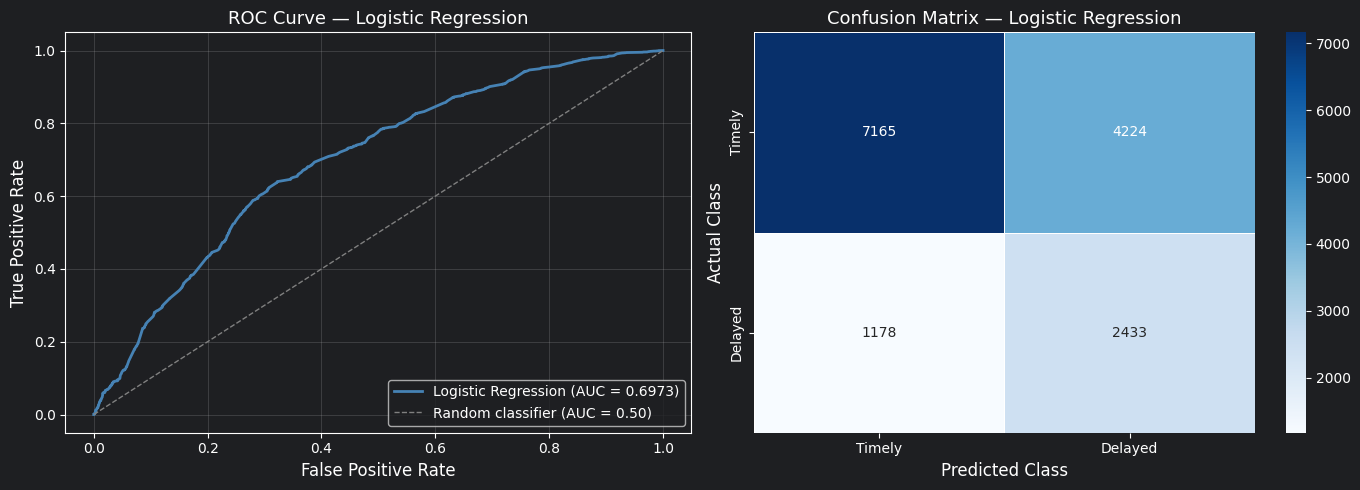

Plot saved to outputs/figures/
VARIABLE IMPORTANCE — TOP 20 COEFFICIENTS
Logistic Regression (standardised coefficients)

  Feature                                        Coefficient  Abs Value
  -------------------------------------------------------------------
  Posted Billing Group_SCHEME RATE(1)                -0.5116     0.5116 -
  Posted Billing Group_MAX / INSURED: 200%(15)       -0.4656     0.4656 -
  Posted Billing Group_MAX / INSURED: 300%(20)       -0.3858     0.3858 -
  Posted Billing Group_Low Billing Rate              -0.3252     0.3252 -
  Age Bracket                                         0.3052     0.3052 +
  Specialty_General Dental Practice                  -0.2784     0.2784 -
  Facility Type_Consulting Rooms                     -0.2744     0.2744 -
  ICD10 Chapter_Routine and Outpatient               -0.2672     0.2672 -
  ICD10 Chapter_Unknown                              -0.2380     0.2380 -
  Posted Billing Group_Medium Billing Rate           -0.2250     0.225

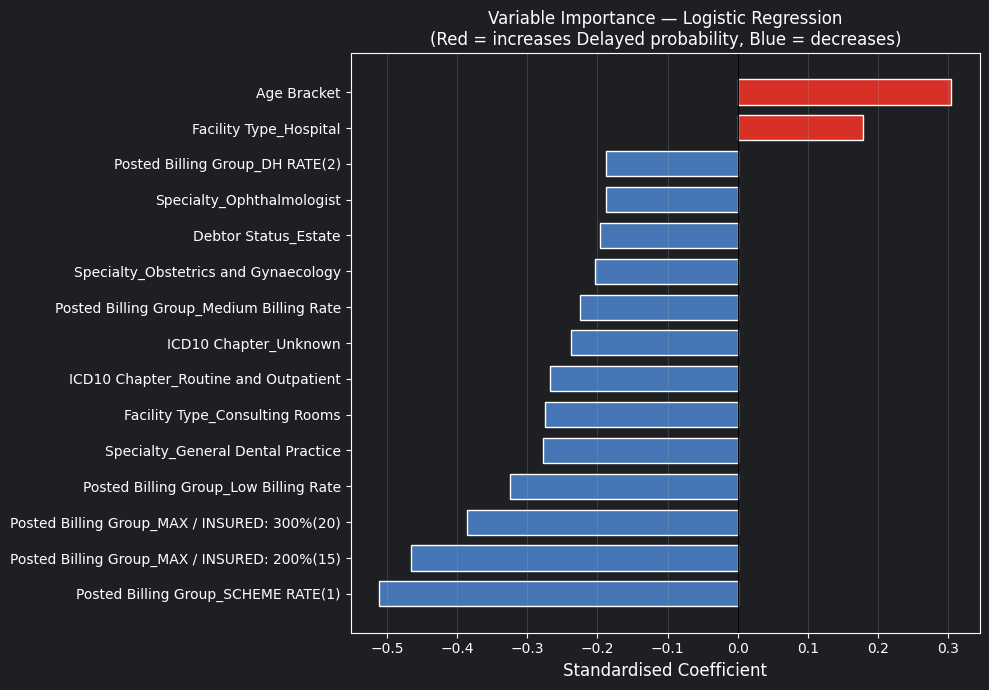

Variable importance plot saved to outputs/figures/


In [6]:
# ============================================================
# CELL 6: VISUALIZATIONS — ROC CURVE AND CONFUSION MATRIX
# We produce two plots for the Logistic Regression model.
# Both are saved to outputs/figures/ for use in the report.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: ROC Curve ─────────────────────────────────────
# Shows the trade-off between true positive rate and false
# positive rate across all classification thresholds
fpr, tpr, thresholds = roc_curve(y_test_enc, y_pred_proba)

axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='grey', lw=1,
             linestyle='--', label='Random classifier (AUC = 0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve — Logistic Regression', fontsize=13)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Confusion Matrix Heatmap ─────────────────────
# Visual representation of the confusion matrix
# Rows = actual class, Columns = predicted class
cm_labels = ['Timely', 'Delayed']
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cm_labels, yticklabels=cm_labels,
    ax=axes[1], cbar=True, linewidths=0.5
)
axes[1].set_xlabel('Predicted Class', fontsize=12)
axes[1].set_ylabel('Actual Class', fontsize=12)
axes[1].set_title('Confusion Matrix — Logistic Regression', fontsize=13)

plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\lr_roc_confusion.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Plot saved to outputs/figures/")

# ============================================================
# CELL 6B: VARIABLE IMPORTANCE — LOGISTIC REGRESSION
# In Logistic Regression variable importance is measured by
# the absolute value of the standardised coefficients.
# Larger absolute coefficients indicate stronger influence
# on the predicted log-odds of being Delayed.
# We show the top 15 most influential encoded predictors.
# ============================================================

# Build coefficient DataFrame
coef_df = pd.DataFrame({
    'Feature':     X_train_enc.columns,
    'Coefficient': lr_model.coef_[0]
})

# Absolute value for importance ranking
coef_df['Abs Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs Coefficient', ascending=False)

print("=" * 60)
print("VARIABLE IMPORTANCE — TOP 20 COEFFICIENTS")
print("Logistic Regression (standardised coefficients)")
print("=" * 60)
print(f"\n  {'Feature':<45} {'Coefficient':>12} {'Abs Value':>10}")
print(f"  {'-'*67}")
for _, row in coef_df.head(20).iterrows():
    direction = '+' if row['Coefficient'] > 0 else '-'
    print(f"  {row['Feature']:<45} "
          f"{row['Coefficient']:>12.4f} "
          f"{row['Abs Coefficient']:>10.4f} {direction}")

# ── Plot top 15 coefficients ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
top15 = coef_df.head(15).sort_values('Coefficient')
colors = ['#d73027' if c > 0 else '#4575b4'
          for c in top15['Coefficient']]

ax.barh(top15['Feature'], top15['Coefficient'],
        color=colors, edgecolor='white', height=0.7)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient', fontsize=12)
ax.set_title('Variable Importance — Logistic Regression\n'
             '(Red = increases Delayed probability, '
             'Blue = decreases)', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    r'C:\2026\MedicalBillingResearch\outputs\figures'
    r'\lr_variable_importance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Variable importance plot saved to outputs/figures/")

In [7]:
# ============================================================
# CELL 7: SAVE LOGISTIC REGRESSION RESULTS
# We save the key metrics to a dictionary that will be
# loaded by the model comparison notebook later.
# We also save the predictions and probabilities so the
# comparison notebook can plot all ROC curves together.
# ============================================================

import json

# ── Save metrics ──────────────────────────────────────────
lr_results = {
    'model':        'Logistic Regression',
    'accuracy':     round(accuracy, 4),
    'auc':          round(auc, 4),
    'f1_delayed':   round(f1_delayed, 4),
    'precision_delayed': round(
        cm[1,1] / (cm[0,1] + cm[1,1]), 4),
    'recall_delayed': round(
        cm[1,1] / (cm[1,0] + cm[1,1]), 4),
    'true_negatives':  int(cm[0,0]),
    'false_positives': int(cm[0,1]),
    'false_negatives': int(cm[1,0]),
    'true_positives':  int(cm[1,1]),
}

# Save metrics to JSON
metrics_path = (
    r'C:\2026\MedicalBillingResearch\models'
    r'\lr_metrics.json'
)
with open(metrics_path, 'w') as f:
    json.dump(lr_results, f, indent=4)

# Save predictions and probabilities for ROC comparison
preds_df = pd.DataFrame({
    'y_true':      y_test_enc,
    'y_pred':      y_pred,
    'y_pred_proba': y_pred_proba
})
preds_df.to_csv(
    r'C:\2026\MedicalBillingResearch\models'
    r'\lr_predictions.csv',
    index=False
)

print("=" * 60)
print("LOGISTIC REGRESSION RESULTS SAVED")
print("=" * 60)
print(f"\n  Metrics saved to : models/lr_metrics.json")
print(f"  Predictions saved: models/lr_predictions.csv")
print(f"\n  Summary:")
for key, val in lr_results.items():
    print(f"    {key:<25} : {val}")

print(f"\n  Logistic Regression notebook — COMPLETE")
print(f"  Next: 03b_decision_tree.ipynb")

LOGISTIC REGRESSION RESULTS SAVED

  Metrics saved to : models/lr_metrics.json
  Predictions saved: models/lr_predictions.csv

  Summary:
    model                     : Logistic Regression
    accuracy                  : 0.6399
    auc                       : 0.6973
    f1_delayed                : 0.4739
    precision_delayed         : 0.3655
    recall_delayed            : 0.6738
    true_negatives            : 7165
    false_positives           : 4224
    false_negatives           : 1178
    true_positives            : 2433

  Logistic Regression notebook — COMPLETE
  Next: 03b_decision_tree.ipynb
